# Modelado de Eventos Climáticos Extremos en Trigo

## Expansión del modelo agroclimático avanzado

En este notebook se incorporan variables climáticas extremas con el objetivo de mejorar la representación de campañas anómalas y aumentar la robustez temporal del modelo agroclimático de trigo.

Los análisis previos mostraron que el modelo basado en promedios climáticos, humedad relativa, VPD y ENSO logró representar adecuadamente campañas normales, pero presentó dificultades frente a campañas extremas.

Esto sugiere que el rendimiento del trigo no depende únicamente de condiciones promedio, sino también de eventos puntuales de alto impacto.

## Objetivos

- Construir variables de eventos climáticos extremos.
- Analizar heladas, olas de calor, sequías y lluvias intensas.
- Integrar estas variables al dataset agroclimático avanzado.
- Evaluar si mejoran el desempeño del modelo.
- Analizar su impacto sobre el backtesting temporal.

## Eventos extremos a incorporar

Se calcularán variables asociadas a:

- días con heladas,
- días de calor extremo,
- días secos,
- lluvias extremas,
- amplitud térmica extrema,
- y persistencia de estrés climático.

## Motivación agroclimática

El trigo es especialmente sensible a eventos extremos durante etapas críticas del ciclo, como macollaje, encañazón, floración y llenado de grano.

Por este motivo, incorporar variables de extremos climáticos puede mejorar la representación de campañas difíciles que no son capturadas por promedios climáticos anuales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_clima = pd.read_csv(
    "../Noaa/clima_rosario_1980_2024_validado.csv"
)

dataset_trigo = pd.read_csv(
    "../Procesados/dataset_trigo_avanzado.csv"
)

In [3]:
df_clima.head()

,fecha,temp_media_c,temp_max_c,temp_min_c,punto_rocio_c,presion_hpa,viento_kmh,precipitacion_original,fog,rain_drizzle,thunder,hail,precipitacion_mm,año
0,1980-01-01,19.83,26.0,10.0,10.67,1016.0,11.48,0.0,0,1,0,0,0.0,1980
1,1980-01-02,22.89,30.0,13.0,12.89,1010.9,18.33,0.0,0,0,0,0,0.0,1980
2,1980-01-03,23.17,30.0,15.0,14.22,1009.9,12.96,0.0,0,0,0,0,0.0,1980
3,1980-01-04,24.78,31.0,18.0,16.44,1011.7,15.19,0.0,0,0,0,0,0.0,1980
4,1980-01-05,23.83,32.0,22.0,17.33,1011.2,12.41,0.0,0,0,0,0,0.0,1980


In [4]:
dataset_trigo.head()

,Campaña,temp_media_c,temp_max_c,temp_min_c,precipitacion_mm,presion_hpa,viento_kmh,niebla,dias_lluvia,trueno,granizo,Cultivo,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,depto_key,score_suelo_promedio,humedad_relativa_prom,humedad_relativa_max,humedad_relativa_min,vpd_prom,vpd_max,vpd_min,amplitud_termica,ENSO_Niña,ENSO_Niño
0,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,CASEROS,82,14,1804,CASEROS,2.516667,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0
1,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,CONSTITUCION,82,28,2004,CONSTITUCION,3.246231,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0
2,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,GENERAL LOPEZ,82,42,1598,GENERAL LOPEZ,2.038107,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0
3,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,IRIONDO,82,56,1817,IRIONDO,2.680162,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0
4,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,ROSARIO,82,84,1812,ROSARIO,3.023256,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0


## Construcción de variables de eventos extremos

A partir del dataset climático diario se construyen variables asociadas a eventos extremos relevantes para el trigo.

Se consideran inicialmente:

- días con heladas,
- días de calor extremo,
- días secos,
- lluvias intensas,
- y amplitud térmica diaria.

Estas variables permiten representar condiciones críticas que pueden afectar el rendimiento durante etapas sensibles del cultivo.

In [5]:
df_clima["fecha"] = pd.to_datetime(df_clima["fecha"])

df_clima["mes"] = df_clima["fecha"].dt.month

df_clima["año_campaña"] = np.where(
    df_clima["mes"] >= 7,
    df_clima["fecha"].dt.year,
    df_clima["fecha"].dt.year - 1
)

df_clima["Campaña"] = (
    df_clima["año_campaña"].astype(str)
    + "/"
    + (df_clima["año_campaña"] + 1).astype(str).str[-2:]
)

In [6]:
# Amplitud térmica diaria
df_clima["amplitud_termica_diaria"] = (
    df_clima["temp_max_c"] - df_clima["temp_min_c"]
)

# Heladas
df_clima["helada"] = (
    df_clima["temp_min_c"] < 0
).astype(int)

# Calor extremo
df_clima["calor_30"] = (
    df_clima["temp_max_c"] > 30
).astype(int)

df_clima["calor_35"] = (
    df_clima["temp_max_c"] > 35
).astype(int)

# Días secos
df_clima["dia_seco"] = (
    df_clima["precipitacion_mm"] == 0
).astype(int)

# Lluvias intensas
df_clima["lluvia_intensa_50"] = (
    df_clima["precipitacion_mm"] > 50
).astype(int)

In [7]:
df_clima[[
    "fecha",
    "Campaña",
    "temp_max_c",
    "temp_min_c",
    "precipitacion_mm",
    "amplitud_termica_diaria",
    "helada",
    "calor_30",
    "calor_35",
    "dia_seco",
    "lluvia_intensa_50"
]].head()

,fecha,Campaña,temp_max_c,temp_min_c,precipitacion_mm,amplitud_termica_diaria,helada,calor_30,calor_35,dia_seco,lluvia_intensa_50
0,1980-01-01,1979/80,26.0,10.0,0.0,16.0,0,0,0,1,0
1,1980-01-02,1979/80,30.0,13.0,0.0,17.0,0,0,0,1,0
2,1980-01-03,1979/80,30.0,15.0,0.0,15.0,0,0,0,1,0
3,1980-01-04,1979/80,31.0,18.0,0.0,13.0,0,1,0,1,0
4,1980-01-05,1979/80,32.0,22.0,0.0,10.0,0,1,0,1,0


## Agregación de eventos extremos por campaña

Las variables extremas diarias se agregan por campaña agrícola para construir indicadores de estrés climático acumulado.

Se calculan:

- cantidad de días con heladas,
- cantidad de días con temperatura máxima mayor a 30°C,
- cantidad de días con temperatura máxima mayor a 35°C,
- cantidad de días secos,
- cantidad de días con lluvia intensa,
- amplitud térmica promedio,
- amplitud térmica máxima.

In [8]:
eventos_extremos = df_clima.groupby("Campaña").agg({

    "helada": "sum",
    "calor_30": "sum",
    "calor_35": "sum",
    "dia_seco": "sum",
    "lluvia_intensa_50": "sum",
    "amplitud_termica_diaria": ["mean", "max"]

}).reset_index()

In [9]:
eventos_extremos.columns = [

    "Campaña",
    "dias_helada",
    "dias_calor_30",
    "dias_calor_35",
    "dias_secos",
    "dias_lluvia_intensa_50",
    "amplitud_termica_prom",
    "amplitud_termica_max"

]

In [10]:
eventos_extremos.head()

,Campaña,dias_helada,dias_calor_30,dias_calor_35,dias_secos,dias_lluvia_intensa_50,amplitud_termica_prom,amplitud_termica_max
0,1979/80,2,52,9,140,1,-19.339218,21.00
1,1980/81,17,57,1,288,4,-2.654027,23.00
2,1981/82,9,63,6,289,3,12.795043,23.00
3,1982/83,5,70,14,277,4,11.689415,21.28
4,1983/84,22,69,7,286,4,11.903989,26.56


In [11]:
temp = df_clima["temp_max_c"].copy()

df_clima["temp_max_c"] = df_clima["temp_min_c"]

df_clima["temp_min_c"] = temp

In [12]:
df_clima[[
    "temp_max_c",
    "temp_min_c"
]].head()

,temp_max_c,temp_min_c
0,10.0,26.0
1,13.0,30.0
2,15.0,30.0
3,18.0,31.0
4,22.0,32.0


In [13]:
# Amplitud térmica diaria
df_clima["amplitud_termica_diaria"] = (
    df_clima["temp_max_c"] -
    df_clima["temp_min_c"]
)

# Heladas
df_clima["helada"] = (
    df_clima["temp_min_c"] < 0
).astype(int)

# Calor extremo
df_clima["calor_30"] = (
    df_clima["temp_max_c"] > 30
).astype(int)

df_clima["calor_35"] = (
    df_clima["temp_max_c"] > 35
).astype(int)

In [14]:
eventos_extremos

,Campaña,dias_helada,dias_calor_30,dias_calor_35,dias_secos,dias_lluvia_intensa_50,amplitud_termica_prom,amplitud_termica_max
0,1979/80,2,52,9,140,1,-19.339218,21.00
1,1980/81,17,57,1,288,4,-2.654027,23.00
2,1981/82,9,63,6,289,3,12.795043,23.00
3,1982/83,5,70,14,277,4,11.689415,21.28
4,1983/84,22,69,7,286,4,11.903989,26.56
5,1984/85,16,39,2,153,1,10.660331,22.61
6,1985/86,3,21,3,0,0,9.295444,17.28
7,1986/87,7,44,3,169,1,10.800000,20.89
8,1987/88,18,56,5,288,2,11.948832,21.11
9,1988/89,17,98,29,296,1,13.719634,24.61


## Integración de eventos extremos al modelo agroclimático

Las variables de eventos extremos son integradas al dataset agroclimático avanzado del trigo con el objetivo de mejorar la representación de campañas climáticamente anómalas y aumentar la capacidad de generalización temporal del modelo.

In [15]:
dataset_trigo_extremos = dataset_trigo.merge(

    eventos_extremos,

    on="Campaña",

    how="left"

)

In [16]:
dataset_trigo_extremos.head()

,Campaña,temp_media_c,temp_max_c,temp_min_c,precipitacion_mm,presion_hpa,viento_kmh,niebla,dias_lluvia,trueno,granizo,Cultivo,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,depto_key,score_suelo_promedio,humedad_relativa_prom,humedad_relativa_max,humedad_relativa_min,vpd_prom,vpd_max,vpd_min,amplitud_termica,ENSO_Niña,ENSO_Niño,dias_helada,dias_calor_30,dias_calor_35,dias_secos,dias_lluvia_intensa_50,amplitud_termica_prom,amplitud_termica_max
0,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,CASEROS,82,14,1804,CASEROS,2.516667,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0,17,57,1,288,4,-2.654027,23.0
1,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,CONSTITUCION,82,28,2004,CONSTITUCION,3.246231,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0,17,57,1,288,4,-2.654027,23.0
2,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,GENERAL LOPEZ,82,42,1598,GENERAL LOPEZ,2.038107,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0,17,57,1,288,4,-2.654027,23.0
3,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,IRIONDO,82,56,1817,IRIONDO,2.680162,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0,17,57,1,288,4,-2.654027,23.0
4,1980/81,17.198411,26.670466,24.016438,1236.98,1014.718356,15.620411,45,103,52,2,Trigo total,SANTA FE,ROSARIO,82,84,1812,ROSARIO,3.023256,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,2.654027,0,0,17,57,1,288,4,-2.654027,23.0


In [17]:
dataset_trigo_extremos.isnull().sum()

Campaña                   0
temp_media_c              0
temp_max_c                0
temp_min_c                0
precipitacion_mm          0
presion_hpa               0
viento_kmh                0
niebla                    0
dias_lluvia               0
trueno                    0
granizo                   0
Cultivo                   0
Provincia                 0
Departamento              0
idProvincia               0
idDepartamento            0
Rendimiento               0
depto_key                 0
score_suelo_promedio      0
humedad_relativa_prom     0
humedad_relativa_max      0
humedad_relativa_min      0
vpd_prom                  0
vpd_max                   0
vpd_min                   0
amplitud_termica          0
ENSO_Niña                 0
ENSO_Niño                 0
dias_helada               0
dias_calor_30             0
dias_calor_35             0
dias_secos                0
dias_lluvia_intensa_50    0
amplitud_termica_prom     0
amplitud_termica_max      0
dtype: int64

## Random Forest incorporando eventos extremos

Se implementa un modelo Random Forest incorporando variables de eventos extremos con el objetivo de evaluar si estas mejoran la capacidad predictiva del modelo agroclimático avanzado del trigo.

Las nuevas variables permiten representar:

- heladas,
- calor extremo,
- sequías,
- lluvias intensas,
- amplitud térmica,
- y estrés climático acumulado.

In [18]:
features_extremos = [

    "temp_media_c",
    "temp_max_c",
    "temp_min_c",
    "amplitud_termica",

    "precipitacion_mm",
    "presion_hpa",
    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "trueno",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min",

    "ENSO_Niña",
    "ENSO_Niño",

    "dias_helada",
    "dias_calor_30",
    "dias_calor_35",
    "dias_secos",
    "dias_lluvia_intensa_50",
    "amplitud_termica_prom",
    "amplitud_termica_max"
]

In [19]:
X = dataset_trigo_extremos[features_extremos]
y = dataset_trigo_extremos["Rendimiento"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
modelo_rf_extremos = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

modelo_rf_extremos.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
pred_extremos = modelo_rf_extremos.predict(X_test)

r2 = r2_score(y_test, pred_extremos)
mae = mean_absolute_error(y_test, pred_extremos)
rmse = np.sqrt(mean_squared_error(y_test, pred_extremos))

print("R²:", round(r2, 3))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

R²: 0.919
MAE: 205.94
RMSE: 285.4


## Modelo OLS incorporando eventos extremos

Se implementa un modelo OLS incorporando variables de eventos climáticos extremos con el objetivo de evaluar su influencia directa sobre el rendimiento agrícola del trigo.

Las nuevas variables permiten representar:

- heladas,
- olas de calor,
- sequías,
- lluvias intensas,
- y amplitud térmica extrema.

El análisis permitirá identificar si los eventos extremos aportan capacidad explicativa adicional al modelo agroclimático.

In [23]:
X = dataset_trigo_extremos[[

    "temp_media_c",
    "temp_max_c",
    "temp_min_c",

    "amplitud_termica",

    "precipitacion_mm",

    "presion_hpa",

    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "trueno",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min",

    "ENSO_Niña",
    "ENSO_Niño",

    "dias_helada",
    "dias_calor_30",
    "dias_calor_35",
    "dias_secos",
    "dias_lluvia_intensa_50",

    "amplitud_termica_prom",
    "amplitud_termica_max"

]]

In [24]:
y = dataset_trigo_extremos["Rendimiento"]

In [25]:
X = sm.add_constant(X)

In [26]:
X = X.astype(float)
y = y.astype(float)

In [27]:
modelo_ols_extremos = sm.OLS(y, X).fit()

In [28]:
print(modelo_ols_extremos.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     10.87
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.90e-27
Time:                        13:56:09   Log-Likelihood:                -2133.4
No. Observations:                 270   AIC:                             4319.
Df Residuals:                     244   BIC:                             4412.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -1.15

## Backtesting temporal con eventos extremos

Se implementa nuevamente el procedimiento de validación temporal incorporando variables asociadas a eventos extremos.

El objetivo es evaluar si estas variables permiten mejorar:

- robustez temporal,
- estabilidad predictiva,
- y representación de campañas climáticamente anómalas.

Particularmente se analizará el comportamiento del modelo frente a campañas extremas previamente identificadas durante el backtesting del modelo avanzado.

In [29]:
dataset_bt = dataset_trigo_extremos.sort_values(
    by="Campaña"
)

In [30]:
campañas = dataset_bt["Campaña"].unique()

In [31]:
resultados_bt_extremos = []

In [32]:
for i in range(15, len(campañas)-1):

    campaña_test = campañas[i]

    campañas_train = campañas[:i]

    train = dataset_bt[
        dataset_bt["Campaña"].isin(campañas_train)
    ]

    test = dataset_bt[
        dataset_bt["Campaña"] == campaña_test
    ]

    X_train = train[[

        "temp_media_c",
        "temp_max_c",
        "temp_min_c",

        "amplitud_termica",

        "precipitacion_mm",

        "presion_hpa",

        "viento_kmh",

        "niebla",
        "dias_lluvia",
        "trueno",
        "granizo",

        "score_suelo_promedio",

        "humedad_relativa_prom",
        "humedad_relativa_max",
        "humedad_relativa_min",

        "vpd_prom",
        "vpd_max",
        "vpd_min",

        "ENSO_Niña",
        "ENSO_Niño",

        "dias_helada",
        "dias_calor_30",
        "dias_calor_35",
        "dias_secos",
        "dias_lluvia_intensa_50",

        "amplitud_termica_prom",
        "amplitud_termica_max"

    ]]

    y_train = train["Rendimiento"]

    X_test = test[[

        "temp_media_c",
        "temp_max_c",
        "temp_min_c",

        "amplitud_termica",

        "precipitacion_mm",

        "presion_hpa",

        "viento_kmh",

        "niebla",
        "dias_lluvia",
        "trueno",
        "granizo",

        "score_suelo_promedio",

        "humedad_relativa_prom",
        "humedad_relativa_max",
        "humedad_relativa_min",

        "vpd_prom",
        "vpd_max",
        "vpd_min",

        "ENSO_Niña",
        "ENSO_Niño",

        "dias_helada",
        "dias_calor_30",
        "dias_calor_35",
        "dias_secos",
        "dias_lluvia_intensa_50",

        "amplitud_termica_prom",
        "amplitud_termica_max"

    ]]

    y_test = test["Rendimiento"]

    modelo_bt = RandomForestRegressor(

        n_estimators=300,
        random_state=42

    )

    modelo_bt.fit(
        X_train,
        y_train
    )

    pred_bt = modelo_bt.predict(X_test)

    r2 = r2_score(
        y_test,
        pred_bt
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred_bt
        )
    )

    resultados_bt_extremos.append({

        "campaña": campaña_test,
        "R2": r2,
        "RMSE": rmse

    })

In [33]:
bt_extremos_df = pd.DataFrame(
    resultados_bt_extremos
)

In [34]:
bt_extremos_df

,campaña,R2,RMSE
0,1995/96,0.259696,213.761958
1,1996/97,-3.229093,433.261945
2,1997/98,-0.097491,395.784547
3,1998/99,-6.510852,597.427683
4,1999/00,-90.451652,906.496709
5,2000/01,-4.112969,413.495845
6,2001/02,-0.787146,356.910048
7,2002/03,-4.733627,280.069990
8,2003/04,-9.095635,766.034472
9,2004/05,-9.609460,812.492579


# Cierre del modelo agroclimático con eventos extremos

En este notebook se incorporaron variables asociadas a eventos climáticos extremos al modelo agroclimático avanzado del trigo.

Se analizaron variables relacionadas con:

- heladas,
- calor extremo,
- amplitud térmica,
- sequías,
- y lluvias intensas.

## Principales hallazgos

Los resultados mostraron que los eventos extremos aportan una mejora importante en la capacidad explicativa del modelo OLS.

Particularmente:

- heladas,
- días de calor extremo,
- y amplitud térmica

mostraron una fuerte relación con el rendimiento agrícola del trigo.

## Interpretación agroclimática

Los resultados sugieren que el trigo presenta una elevada sensibilidad frente a eventos climáticos puntuales y extremos térmicos.

Esto refuerza la hipótesis de que el cultivo responde fuertemente a:

- estrés térmico,
- estrés evaporativo,
- y eventos intraestacionales críticos.

## Backtesting temporal

Aunque las variables extremas mejoraron parcialmente algunas campañas problemáticas, el modelo continuó mostrando dificultades para generalizar frente a campañas climáticamente anómalas.

Esto sugiere que:

- la agregación anual suaviza señales críticas,
- y que probablemente existan procesos intraestacionales y fenológicos aún no representados.

## Conclusión general

El análisis permitió demostrar que:

- las variables atmosféricas avanzadas son fundamentales para explicar el rendimiento del trigo,
- los eventos extremos mejoran significativamente la interpretación física del sistema,
- y que las campañas extremas poseen dinámicas climáticas complejas que requieren análisis específicos de alta resolución temporal.

## Próxima etapa

En el siguiente notebook se realizará un análisis detallado de campañas extremas con el objetivo de identificar:

- anomalías climáticas,
- patrones fuera de régimen,
- y posibles causas físicas de los colapsos predictivos observados durante el backtesting temporal.

In [35]:
dataset_trigo_extremos.to_csv(

    "../Procesados/dataset_trigo_eventos_extremos.csv",

    index=False

)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
dataset_trigo = pd.read_csv(
    "../../Procesados/dataset_trigo_eventos_extremos.csv"
)

In [3]:
features_trigo = [

    "temp_media_c",
    "temp_max_c",
    "temp_min_c",
    "amplitud_termica",

    "precipitacion_mm",
    "presion_hpa",
    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "trueno",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min",

    "ENSO_Niña",
    "ENSO_Niño",

    "dias_helada",
    "dias_calor_30",
    "dias_calor_35",
    "dias_secos",
    "dias_lluvia_intensa_50",

    "amplitud_termica_prom",
    "amplitud_termica_max"

]

X = dataset_trigo[features_trigo]
y = dataset_trigo["Rendimiento"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

modelo_rf_final = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

predicciones = modelo_rf_final.predict(X_test)

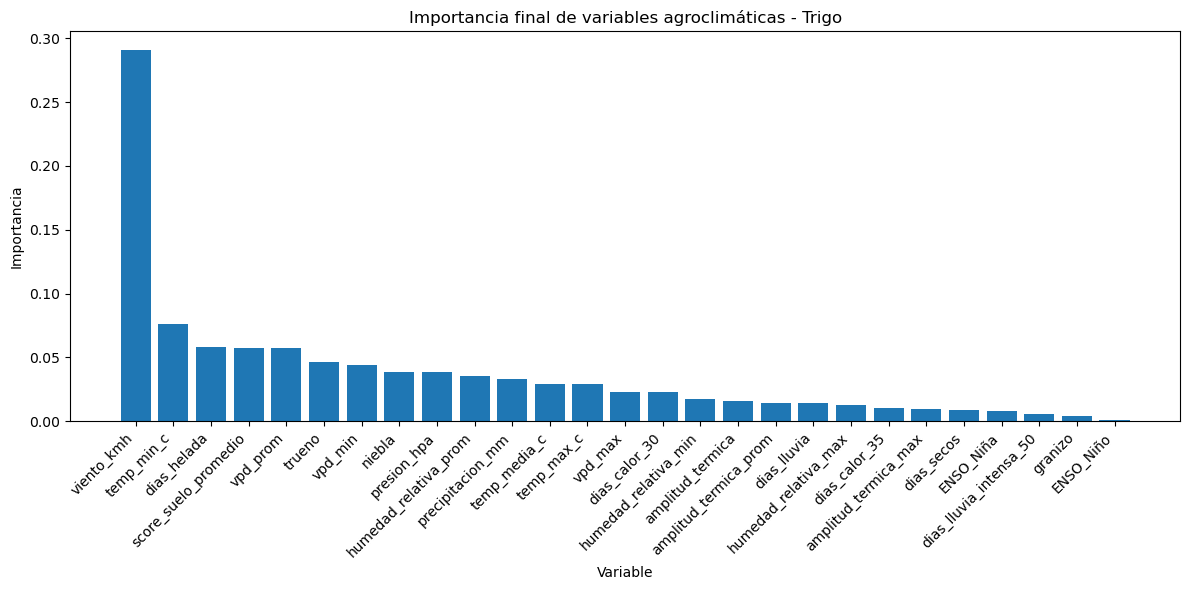

In [4]:
importancias_trigo = pd.DataFrame({

    "Variable": X.columns,
    "Importancia": modelo_rf_final.feature_importances_

}).sort_values(
    by="Importancia",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    importancias_trigo["Variable"],
    importancias_trigo["Importancia"]
)

plt.title("Importancia final de variables agroclimáticas - Trigo")
plt.xlabel("Variable")
plt.ylabel("Importancia")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "../../Dashboard/importancia_variables_trigo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

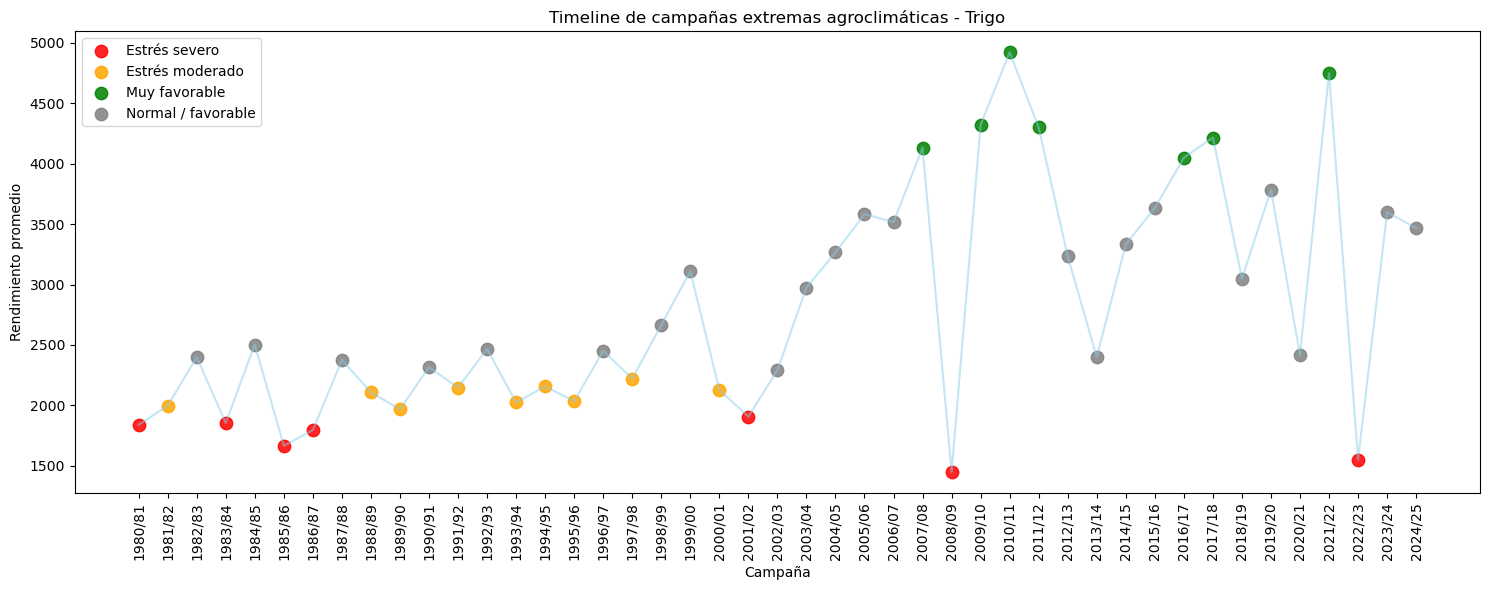

In [5]:
trigo_timeline = dataset_trigo.groupby("Campaña").agg({
    "Rendimiento": "mean"
}).reset_index()

trigo_timeline["año_inicio"] = (
    trigo_timeline["Campaña"]
    .str.split("/")
    .str[0]
    .astype(int)
)

trigo_timeline = trigo_timeline.sort_values(
    by="año_inicio"
)

trigo_timeline["tipo_campaña"] = "Normal / favorable"

trigo_timeline.loc[
    trigo_timeline["Rendimiento"] <= trigo_timeline["Rendimiento"].quantile(0.15),
    "tipo_campaña"
] = "Estrés severo"

trigo_timeline.loc[
    (trigo_timeline["Rendimiento"] > trigo_timeline["Rendimiento"].quantile(0.15)) &
    (trigo_timeline["Rendimiento"] <= trigo_timeline["Rendimiento"].quantile(0.35)),
    "tipo_campaña"
] = "Estrés moderado"

trigo_timeline.loc[
    trigo_timeline["Rendimiento"] >= trigo_timeline["Rendimiento"].quantile(0.85),
    "tipo_campaña"
] = "Muy favorable"

colores = {
    "Estrés severo": "red",
    "Estrés moderado": "orange",
    "Muy favorable": "green",
    "Normal / favorable": "gray"
}

plt.figure(figsize=(15,6))

plt.plot(
    trigo_timeline["año_inicio"],
    trigo_timeline["Rendimiento"],
    color="skyblue",
    alpha=0.5
)

for tipo, color in colores.items():

    datos = trigo_timeline[
        trigo_timeline["tipo_campaña"] == tipo
    ]

    plt.scatter(
        datos["año_inicio"],
        datos["Rendimiento"],
        color=color,
        label=tipo,
        alpha=0.85,
        s=80
    )

plt.title("Timeline de campañas extremas agroclimáticas - Trigo")
plt.xlabel("Campaña")
plt.ylabel("Rendimiento promedio")

plt.xticks(
    trigo_timeline["año_inicio"],
    trigo_timeline["Campaña"],
    rotation=90
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "../../Dashboard/timeline_campañas_extremas_trigo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

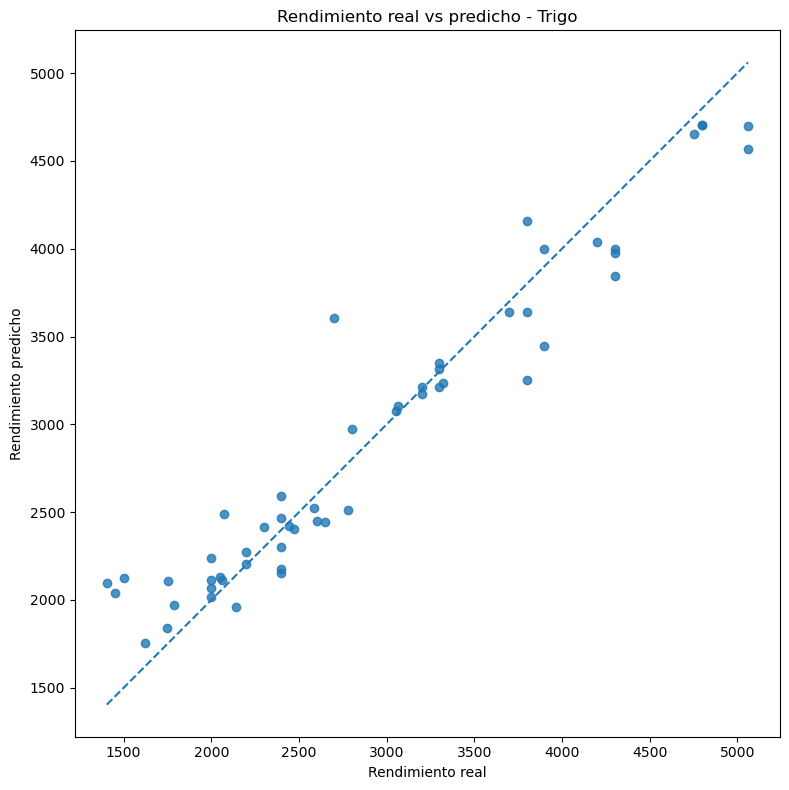

In [6]:
resultados_pred_trigo = pd.DataFrame({

    "Real": y_test.values,
    "Predicho": predicciones

})

plt.figure(figsize=(8,8))

plt.scatter(
    resultados_pred_trigo["Real"],
    resultados_pred_trigo["Predicho"],
    alpha=0.8
)

plt.plot(
    [
        resultados_pred_trigo["Real"].min(),
        resultados_pred_trigo["Real"].max()
    ],
    [
        resultados_pred_trigo["Real"].min(),
        resultados_pred_trigo["Real"].max()
    ],
    linestyle="--"
)

plt.title("Rendimiento real vs predicho - Trigo")
plt.xlabel("Rendimiento real")
plt.ylabel("Rendimiento predicho")

plt.tight_layout()

plt.savefig(
    "../../Dashboard/real_vs_predicho_trigo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()